In [37]:
from pathlib import Path

import numpy as np
import pandas as pd
from pandas.plotting import autocorrelation_plot
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [2]:
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 5)

TRACK = "team"
TRAIN_DAYS = 14
MAX_TRAIN_ROWS = 1_500_000
RIDGE_ALPHA = 4.0
RANDOM_STATE = 42

TRACK_CONFIG = {
    "solo": {
        "train_path": "train_solo_track.parquet",
        "test_path": "test_solo_track.parquet",
        "target_col": "target_1h",
        "forecast_points": 8,
    },
    "team": {
        "train_path": "../data/train_team_track.parquet",
        "test_path": "../data/test_team_track.parquet",
        "target_col": "target_2h",
        "forecast_points": 10,
    },
}

CONFIG = TRACK_CONFIG[TRACK]
TARGET_COL = CONFIG["target_col"]


In [3]:
train_df = pd.read_parquet(CONFIG['train_path'])
test_df = pd.read_parquet(CONFIG['test_path'])

train_df['timestamp'] = pd.to_datetime(train_df['timestamp'])
test_df['timestamp'] = pd.to_datetime(test_df['timestamp'])

train_df = train_df.sort_values(['route_id', 'timestamp']).reset_index(drop=True)
test_df = test_df.sort_values(['route_id', 'timestamp']).reset_index(drop=True)

In [5]:
print("track:", TRACK)
print("train shape:", train_df.shape)
print("test shape:", test_df.shape)

track: team
train shape: (4342000, 12)
test shape: (10000, 3)


In [7]:
display(train_df.head())
display(test_df.head())

,office_from_id,route_id,timestamp,status_1,status_2,status_3,status_4,status_5,status_6,status_7,status_8,target_2h
0,26,0,2025-03-01 00:00:00,0,46,0,0,12,9,0,0,79.0
1,26,0,2025-03-01 00:30:00,0,34,0,0,16,0,187,0,88.0
2,26,0,2025-03-01 01:00:00,0,19,0,0,31,0,0,0,88.0
3,26,0,2025-03-01 01:30:00,0,33,0,0,36,129,0,0,88.0
4,26,0,2025-03-01 02:00:00,0,24,0,0,55,12,0,0,103.0


,id,route_id,timestamp
0,4900,0,2025-05-30 11:00:00
1,4901,0,2025-05-30 11:30:00
2,4902,0,2025-05-30 12:00:00
3,4903,0,2025-05-30 12:30:00
4,4904,0,2025-05-30 13:00:00


In [7]:
print("Train date range:", train_df["timestamp"].min(), "->", train_df["timestamp"].max())
print("Test date range:", test_df["timestamp"].min(), "->", test_df["timestamp"].max())
print("Train routes:", train_df["route_id"].nunique())
print("Test routes:", test_df["route_id"].nunique())
print('Train offices from:', train_df['office_from_id'].nunique())

Train date range: 2025-03-01 00:00:00 -> 2025-05-30 10:30:00
Test date range: 2025-05-30 11:00:00 -> 2025-05-30 15:30:00
Train routes: 1000
Test routes: 1000
Train offices from: 53


In [8]:
overview = pd.DataFrame(
    {
        'dtype': train_df.dtypes.astype(str),
        'missing_cnt': train_df.isna().sum(),
        'missing_pct': (train_df.isna().mean()*100).round(4),
        'n_unique': train_df.nunique(dropna=False)
    }
)
overview

,dtype,missing_cnt,missing_pct,n_unique
office_from_id,int64,0,0.0,53
route_id,int64,0,0.0,1000
timestamp,datetime64[ns],0,0.0,4342
status_1,int64,0,0.0,19752
status_2,int64,0,0.0,2127
status_3,int64,0,0.0,17998
status_4,int64,0,0.0,14416
status_5,int64,0,0.0,17108
status_6,int64,0,0.0,17616
status_7,int64,0,0.0,38219


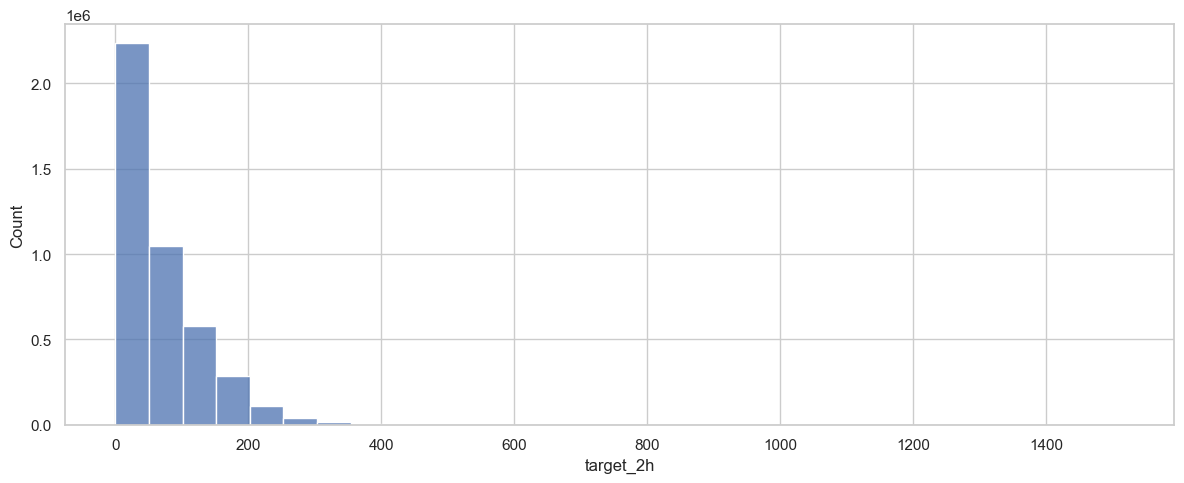

In [10]:
sns.histplot(train_df['target_2h'], bins=30, kde=False)
plt.tight_layout()
plt.show()

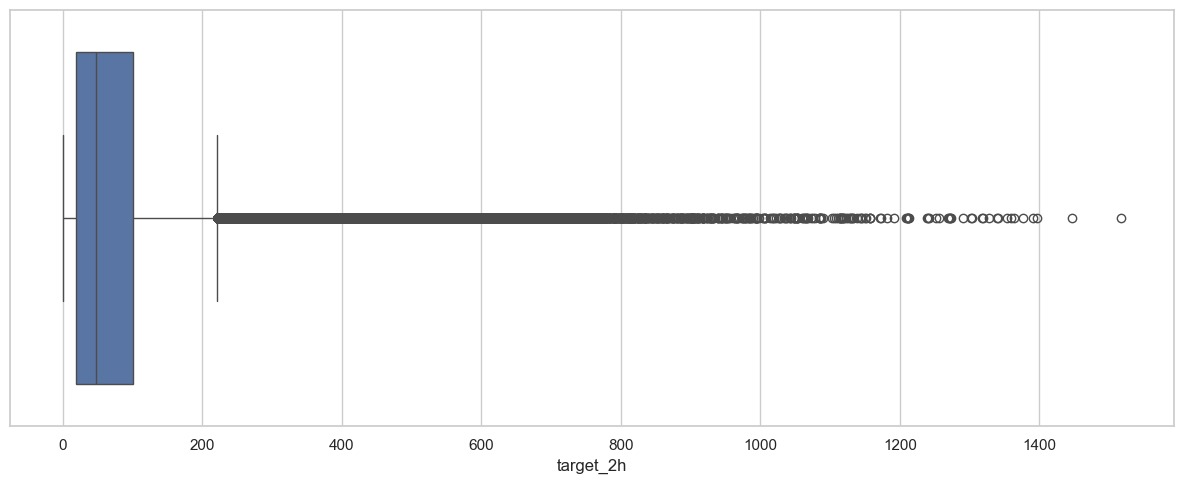

In [6]:
sns.boxplot(train_df, x='target_2h')
plt.tight_layout()
plt.show()

In [26]:
route_2h_target = train_df.groupby(['route_id'])['target_2h'].mean().reset_index(name='avg_target_2h')
route_2h_target.sort_values('avg_target_2h')

,route_id,avg_target_2h
407,407,0.000000
124,124,0.000000
582,582,0.000000
450,450,0.000000
364,364,0.000000
...,...,...
340,340,247.232381
537,537,254.009212
956,956,265.488715
960,960,284.372639


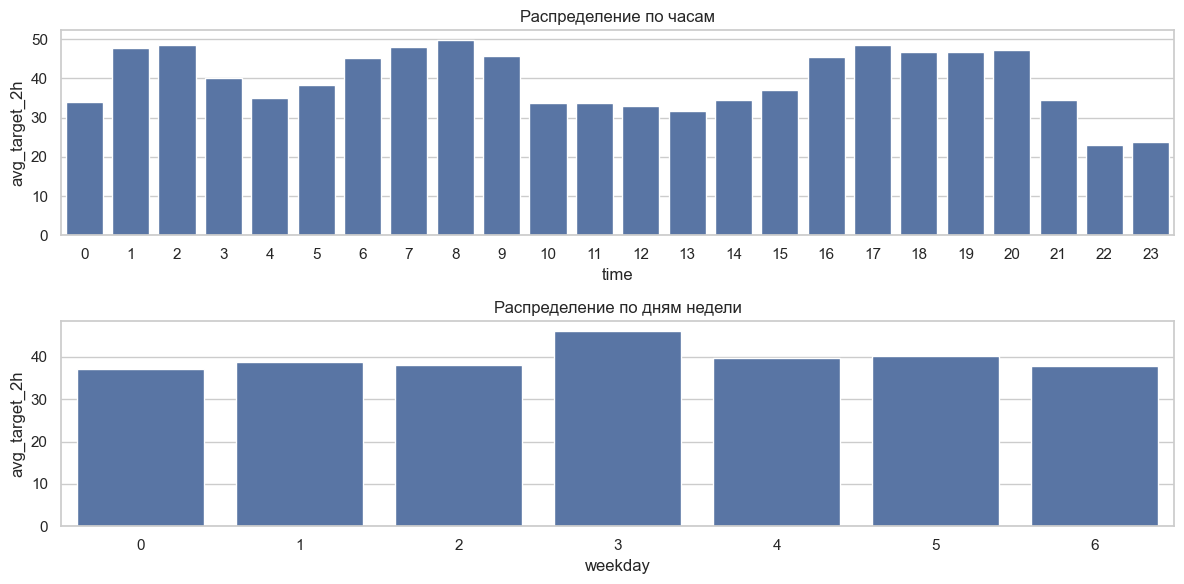

In [25]:
route0_df = train_df.loc[train_df['route_id']==0, ['route_id', 'timestamp', 'target_2h']]
route0_df['time'] = route0_df['timestamp'].dt.hour
route0_df['weekday'] = route0_df['timestamp'].dt.weekday
route0_time = route0_df.groupby(['time'])['target_2h'].mean().reset_index(name='avg_target_2h')
route0_weekday = route0_df.groupby(['weekday'])['target_2h'].mean().reset_index(name='avg_target_2h')

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
sns.barplot(route0_time, x='time', y='avg_target_2h')
plt.title('Распределение по часам')

plt.subplot(2, 1, 2)
sns.barplot(route0_weekday, x='weekday', y='avg_target_2h')
plt.title('Распределение по дням недели')

plt.tight_layout()
plt.show()

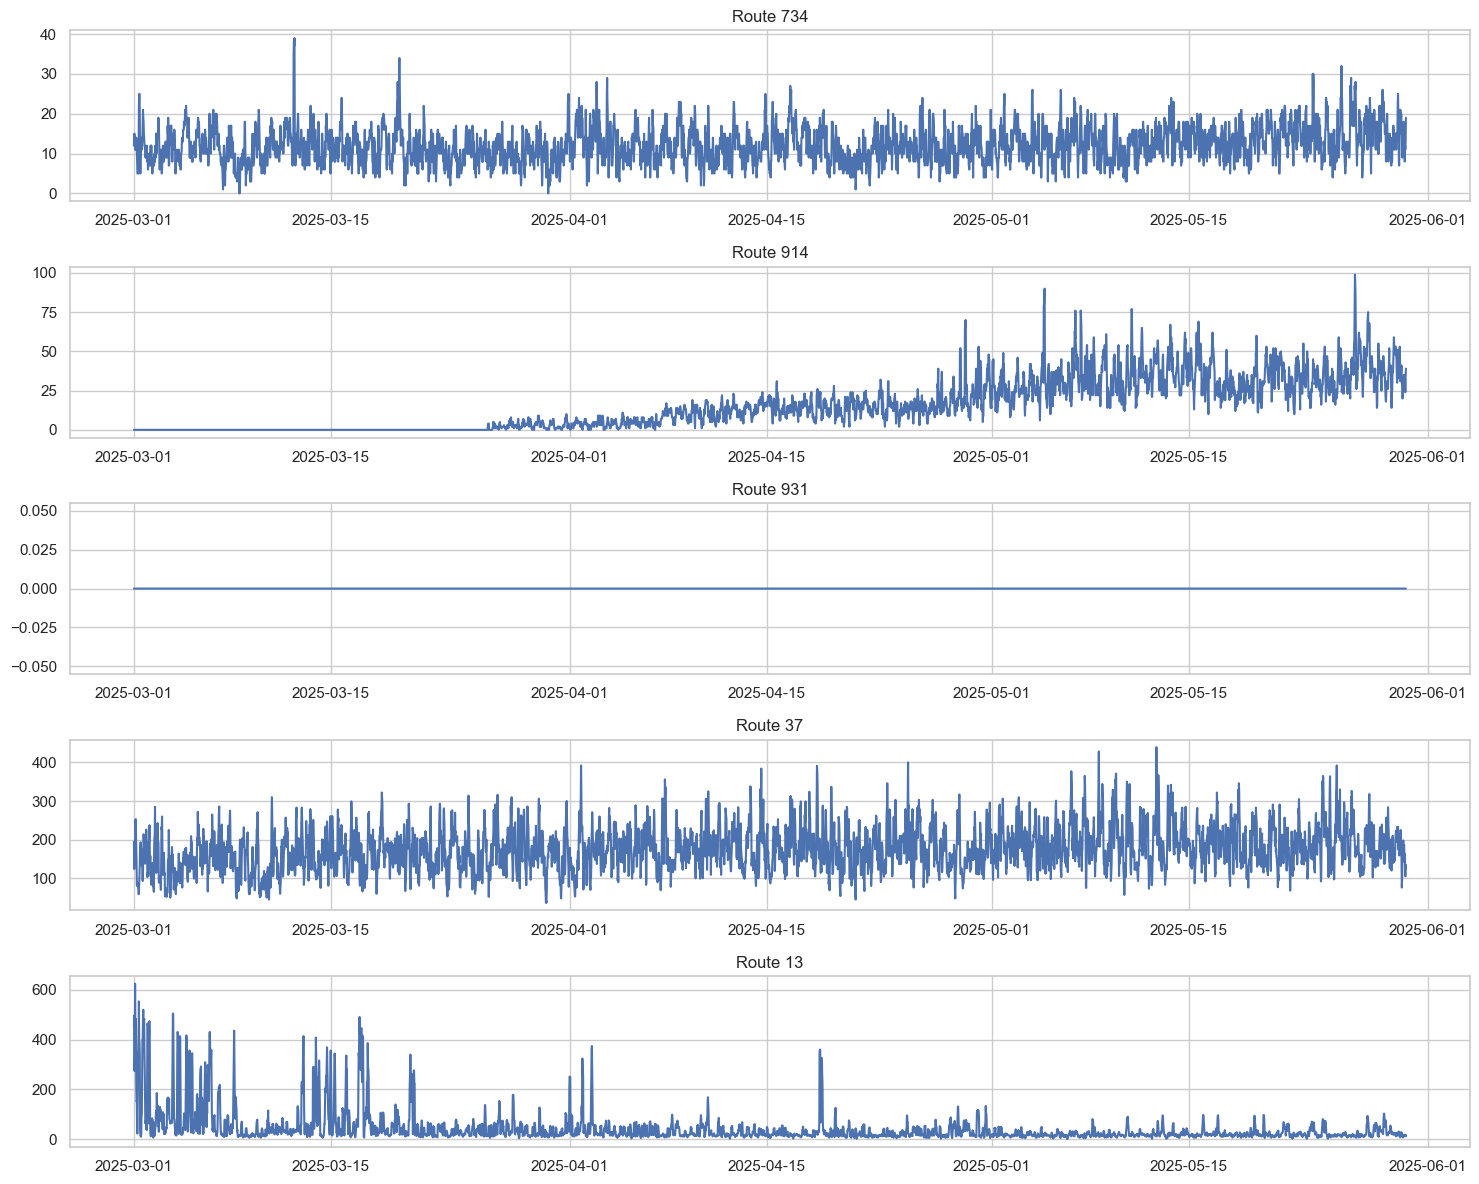

In [26]:
sample_routes = train_df['route_id'].sample(5, random_state=101)

fig, axes = plt.subplots(5, 1, figsize=(15, 12))
for ax, id in zip(axes, sample_routes):
    route_df = train_df[train_df['route_id']==id]
    ax.plot(route_df['timestamp'], route_df['target_2h'])
    ax.set_title(f'Route {id}')

plt.tight_layout()
plt.show()

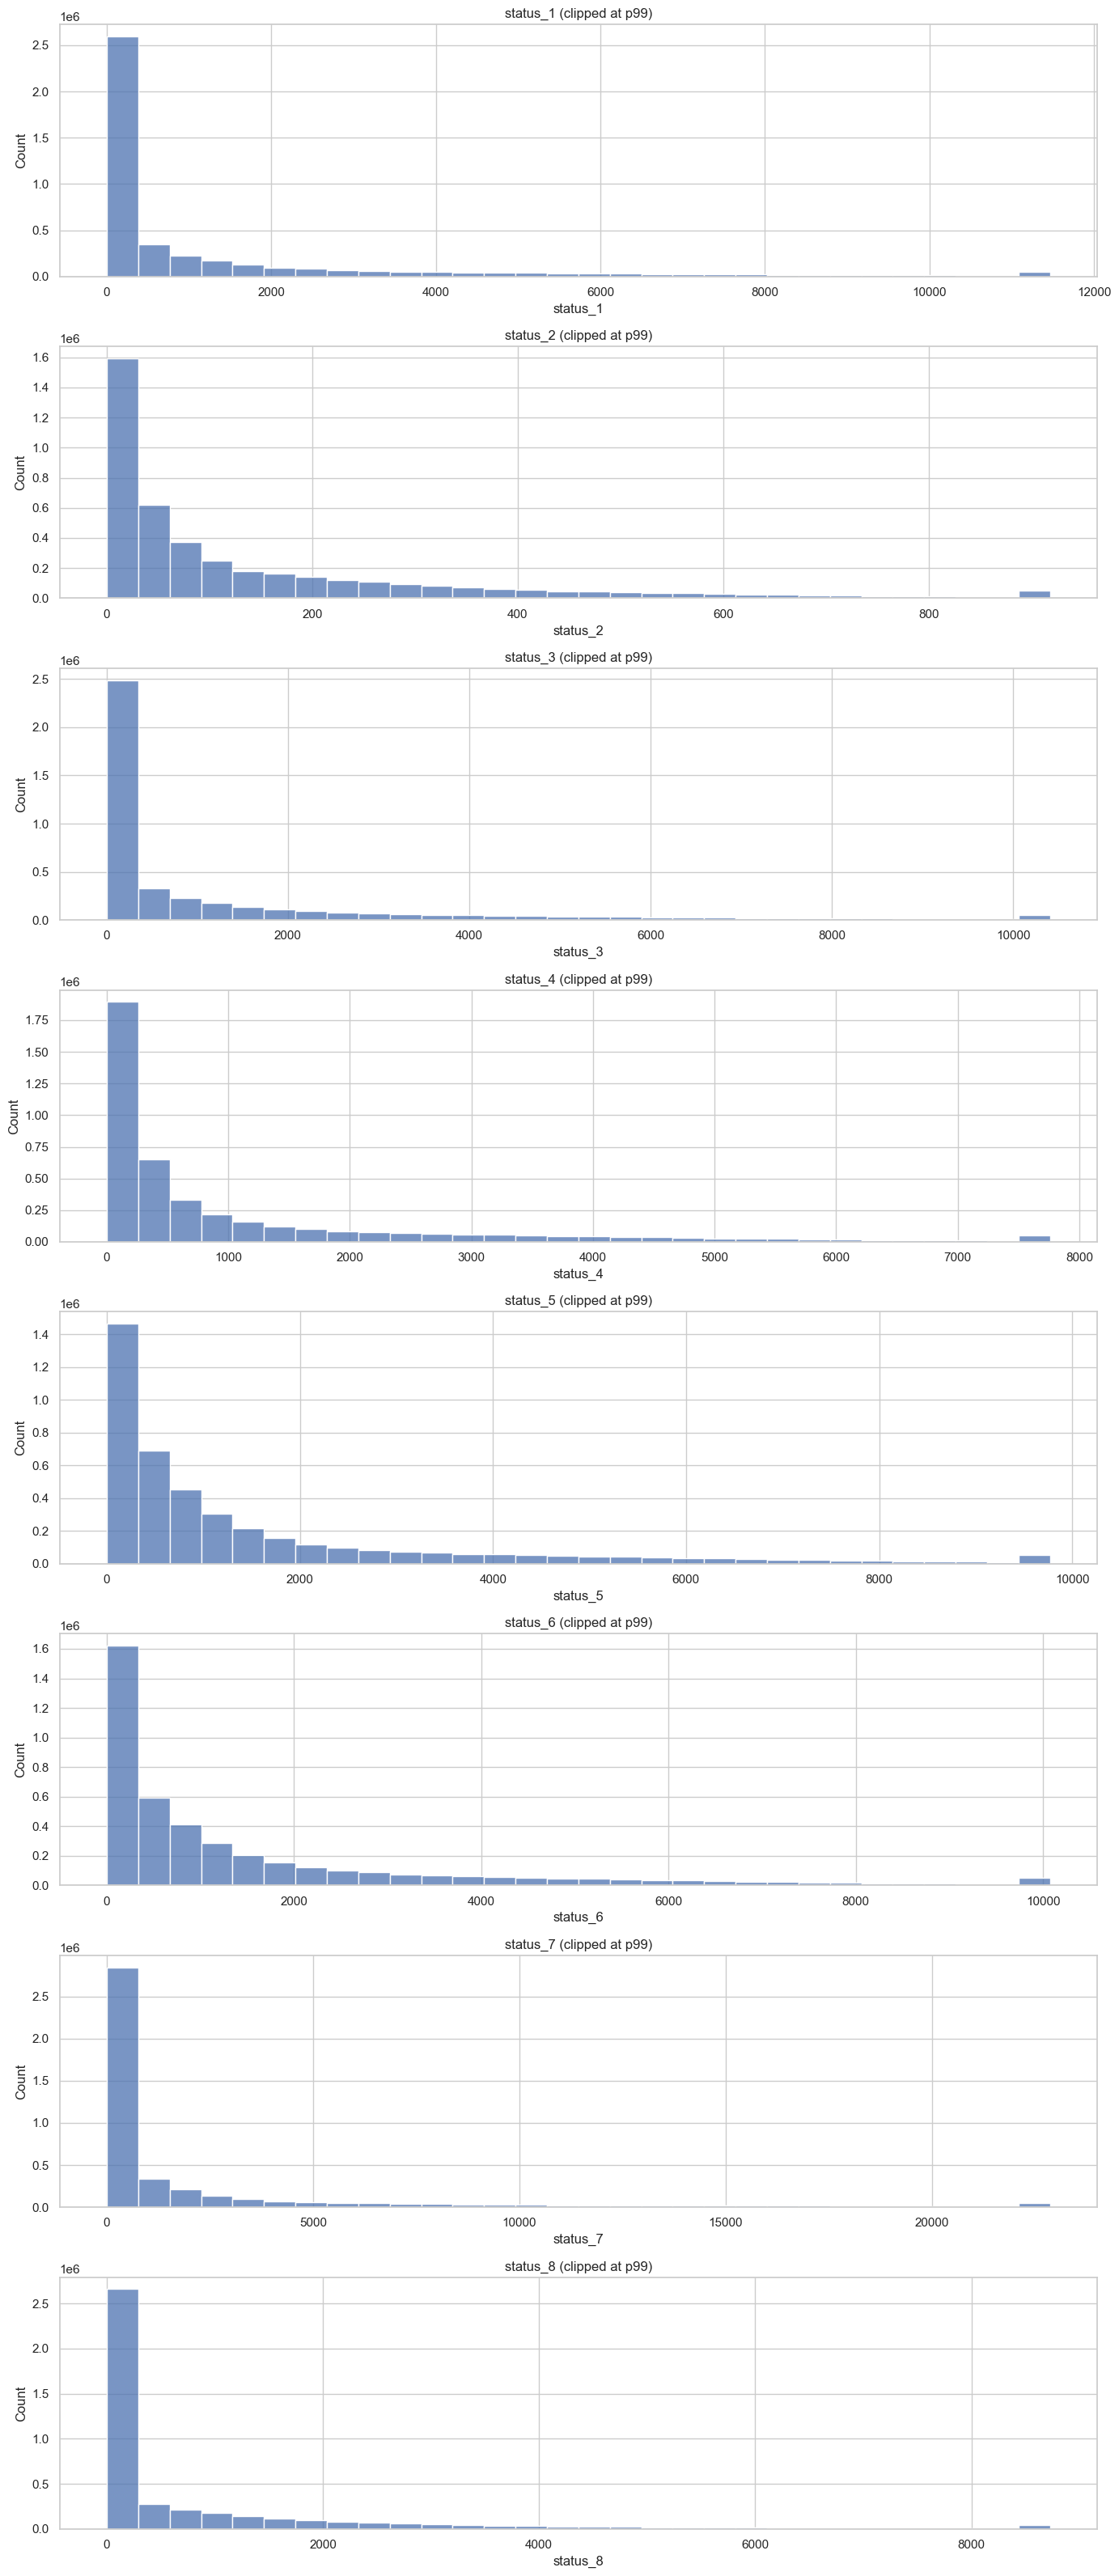

In [21]:
statuses = []
for i in range(1, 9):
    statuses.append(f'status_{i}')

fig, axes = plt.subplots(8, 1, figsize=(14, 4*len(statuses)))
for i, col in enumerate(statuses):
    sns.histplot(train_df[col].clip(upper=train_df[col].quantile(0.99)), bins=30, kde=False, ax=axes[i])
    axes[i].set_title(f'{col} (clipped at p99)')

plt.tight_layout()
plt.show()

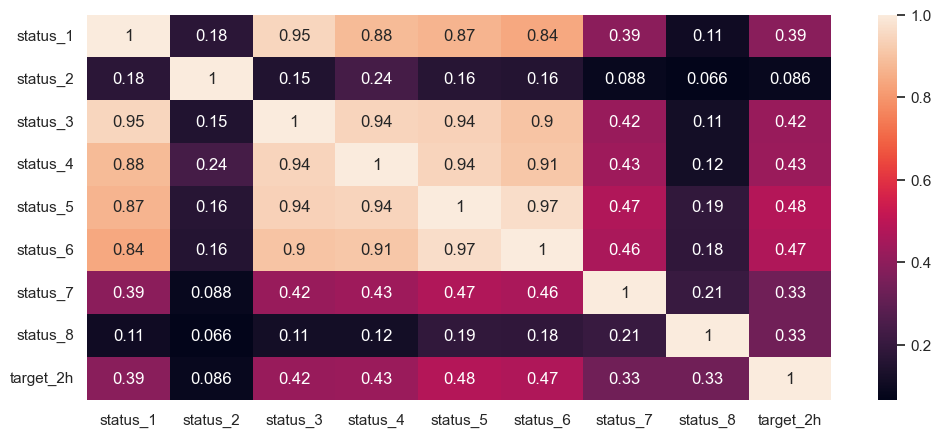

In [9]:
corr_df = train_df[statuses+['target_2h']].corr()
sns.heatmap(corr_df, annot=True)
plt.show()

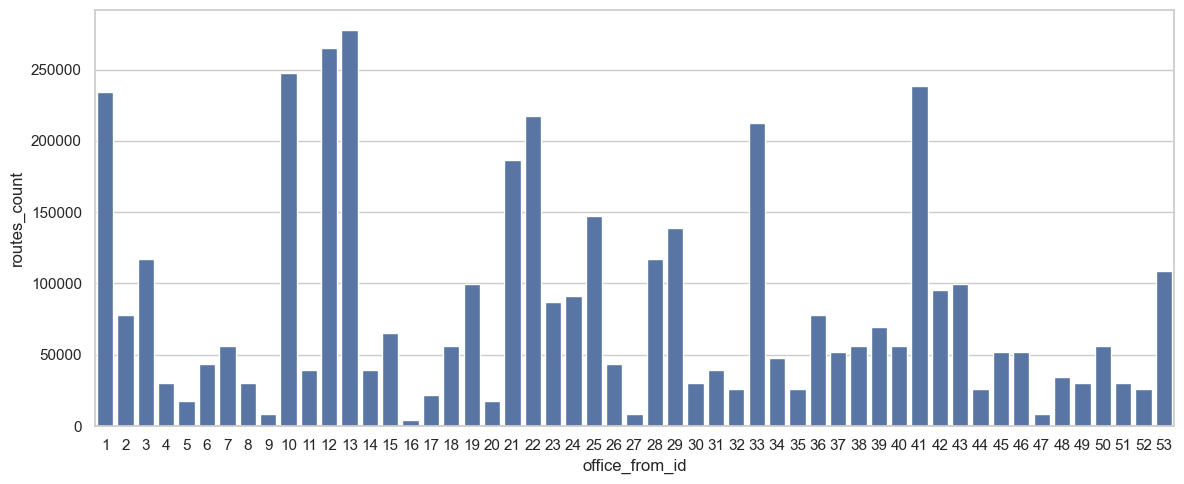

In [12]:
office_route_df = train_df.groupby(['office_from_id'])['route_id'].count().reset_index(name='routes_count')
sns.barplot(office_route_df, x='office_from_id', y='routes_count')
plt.tight_layout()
plt.show()

In [20]:
route_avg_df = train_df.groupby(['route_id'])['target_2h'].mean().sort_values(ascending=False)
route_avg_df.head(10)

route_id
79     288.480424
960    284.372639
956    265.488715
537    254.009212
340    247.232381
827    241.623906
706    237.321511
268    234.660755
641    234.151543
409    232.024182
Name: target_2h, dtype: float64

In [30]:
corr_status = train_df[statuses+[TARGET_COL]].corr()[TARGET_COL].drop(TARGET_COL).sort_values(ascending=False)
corr_status

status_5    0.481257
status_6    0.468166
status_4    0.426476
status_3    0.422644
status_1    0.389965
status_8    0.334934
status_7    0.332776
status_2    0.085748
Name: target_2h, dtype: float64

In [36]:
important_statuses = corr_status[corr_status>0.3].index.tolist()
lags = range(1, 13)
corr_matrix = pd.DataFrame(index=lags, columns=important_statuses)
for status in important_statuses:
    for lag in lags:
        shifted = train_df.groupby('route_id')[status].shift(lag)
        corr = shifted.corr(train_df[TARGET_COL]).round(3)
        corr_matrix.loc[lag, status] = corr

corr_matrix

,status_5,status_6,status_4,status_3,status_1,status_8,status_7
1,0.484,0.473,0.43,0.427,0.395,0.354,0.329
2,0.486,0.474,0.433,0.432,0.401,0.364,0.323
3,0.486,0.475,0.434,0.435,0.406,0.369,0.309
4,0.485,0.471,0.434,0.437,0.41,0.364,0.304
5,0.482,0.465,0.433,0.438,0.414,0.344,0.305
6,0.478,0.462,0.431,0.437,0.417,0.336,0.305
7,0.475,0.458,0.427,0.435,0.419,0.333,0.304
8,0.471,0.455,0.424,0.433,0.42,0.331,0.303
9,0.467,0.452,0.419,0.429,0.419,0.331,0.303
10,0.463,0.448,0.415,0.425,0.418,0.33,0.301


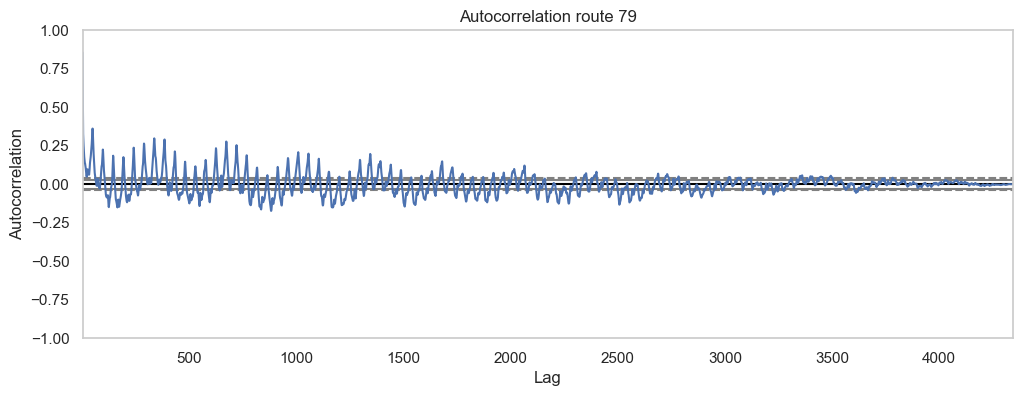

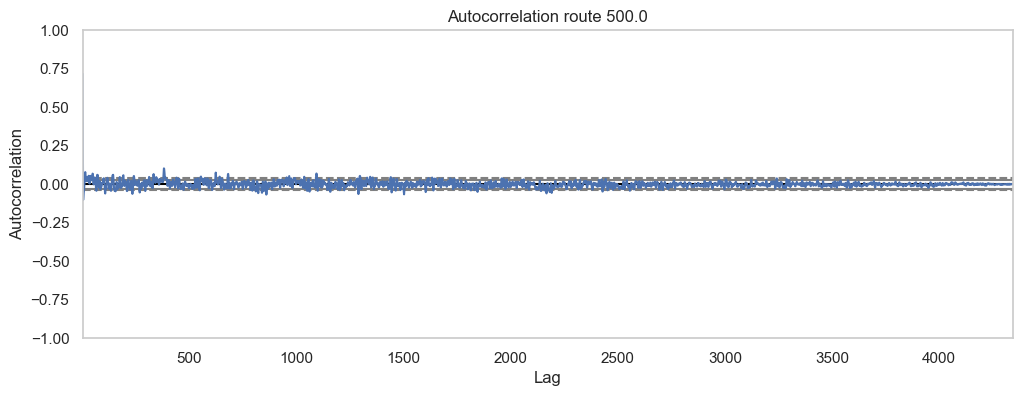

c:\Users\User\rwb-warehouse-logistics-automation\venv\Lib\site-packages\pandas\plotting\_matplotlib\misc.py:456: RuntimeWarning: invalid value encountered in scalar divide
  return ((data[: n - h] - mean) * (data[h:] - mean)).sum() / n / c0


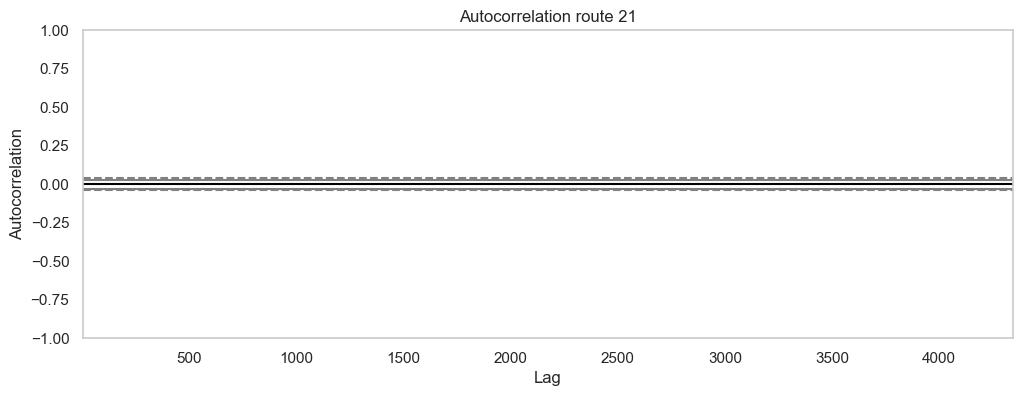

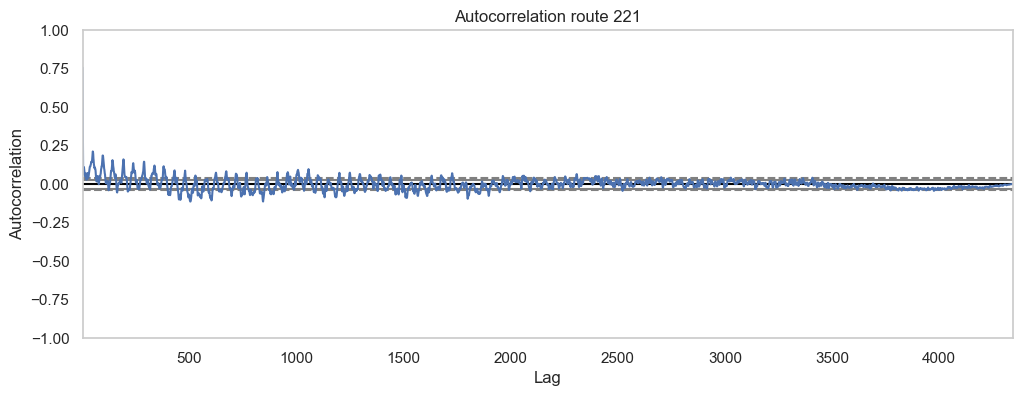

In [45]:
route_avg = train_df.groupby(['route_id'])[TARGET_COL].mean().reset_index()
route_avg.columns = ['route_id', 'avg_target_2h']

high_route = route_avg.nlargest(1, 'avg_target_2h')['route_id'].iloc[0]
low_route = route_avg.nsmallest(1, 'avg_target_2h')['route_id'].iloc[0]
mid_route = route_avg.iloc[len(route_avg)//2]['route_id']
random_route = route_avg.sample(1)['route_id'].iloc[0]

for route in [high_route, mid_route, low_route, random_route]:
    route_data = train_df[train_df['route_id']==route][TARGET_COL]
    plt.figure(figsize=(12, 4))
    autocorrelation_plot(route_data)
    plt.title(f'Autocorrelation route {route}')
    plt.show()